In [5]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

cwd = Path.cwd().resolve()
repo_root = cwd.parent.parent
sys.path.insert(0, str(repo_root / 'src'))

from paper_plots.style_utils import set_paper_style
set_paper_style()

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

%config InlineBackend.figure_format = 'retina'


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# RMSD trajectories (single run)

This notebook plots a single RMSD trajectory for WT, D2M, and Y0A from COLVAR files.


In [6]:
from common.colvar_utils import load_colvar, read_colvar_header_names
from common.consts import res_colors

data_root = repo_root / "data"
traj_root = data_root / "hlda_trajectories"

mutants = ["WT", "T5R", "Y9A"]

def resolve_colvar_path(mutant: str) -> Path:
    colvar_path = traj_root / mutant / "COLVAR_CV_F"
    if not colvar_path.exists():
        raise FileNotFoundError(
            f"Expected folded HLDA trajectory file for {mutant} at {colvar_path}, but it does not exist."
        )
    print(f"{mutant}: using folded HLDA trajectory {colvar_path}")
    return colvar_path

def pick_rmsd_column(path: Path) -> str:
    names = read_colvar_header_names(path)
    for candidate in ["rmsd_ca", "rmsd"]:
        if candidate in names:
            return candidate
    raise ValueError(f"No RMSD column found in {path}")

traj_data = {}
for mutant in mutants:
    colvar_path = resolve_colvar_path(mutant)
    rmsd_col = pick_rmsd_column(colvar_path)
    usecols = ["time", rmsd_col]
    df = load_colvar(colvar_path, usecols=usecols, nrows=None)
    df = df.rename(columns={rmsd_col: "rmsd"})
    traj_data[mutant] = df

traj_data


WT: using folded HLDA trajectory /home/alexz/Repos/guiding-peptide-kinetics/data/hlda_trajectories/WT/COLVAR_CV_F
T5R: using folded HLDA trajectory /home/alexz/Repos/guiding-peptide-kinetics/data/hlda_trajectories/T5R/COLVAR_CV_F
Y9A: using folded HLDA trajectory /home/alexz/Repos/guiding-peptide-kinetics/data/hlda_trajectories/Y9A/COLVAR_CV_F


{'WT':             time      rmsd
 0            0.0  0.062310
 1            1.0  0.065245
 2            2.0  0.074410
 3            3.0  0.074204
 4            4.0  0.085510
 ...          ...       ...
 99996    99996.0  0.154060
 99997    99997.0  0.154424
 99998    99998.0  0.150090
 99999    99999.0  0.158997
 100000  100000.0  0.162961
 
 [100001 rows x 2 columns],
 'T5R':             time      rmsd
 0            0.0  0.064831
 1            1.0  0.071218
 2            2.0  0.080528
 3            3.0  0.098552
 4            4.0  0.112155
 ...          ...       ...
 99996    99996.0  0.255988
 99997    99997.0  0.242517
 99998    99998.0  0.242619
 99999    99999.0  0.239709
 100000  100000.0  0.245072
 
 [100001 rows x 2 columns],
 'Y9A':             time      rmsd
 0            0.0  0.068931
 1            1.0  0.073534
 2            2.0  0.073945
 3            3.0  0.094686
 4            4.0  0.130032
 ...          ...       ...
 99996    99996.0  0.186001
 99997    99997.0  0.182

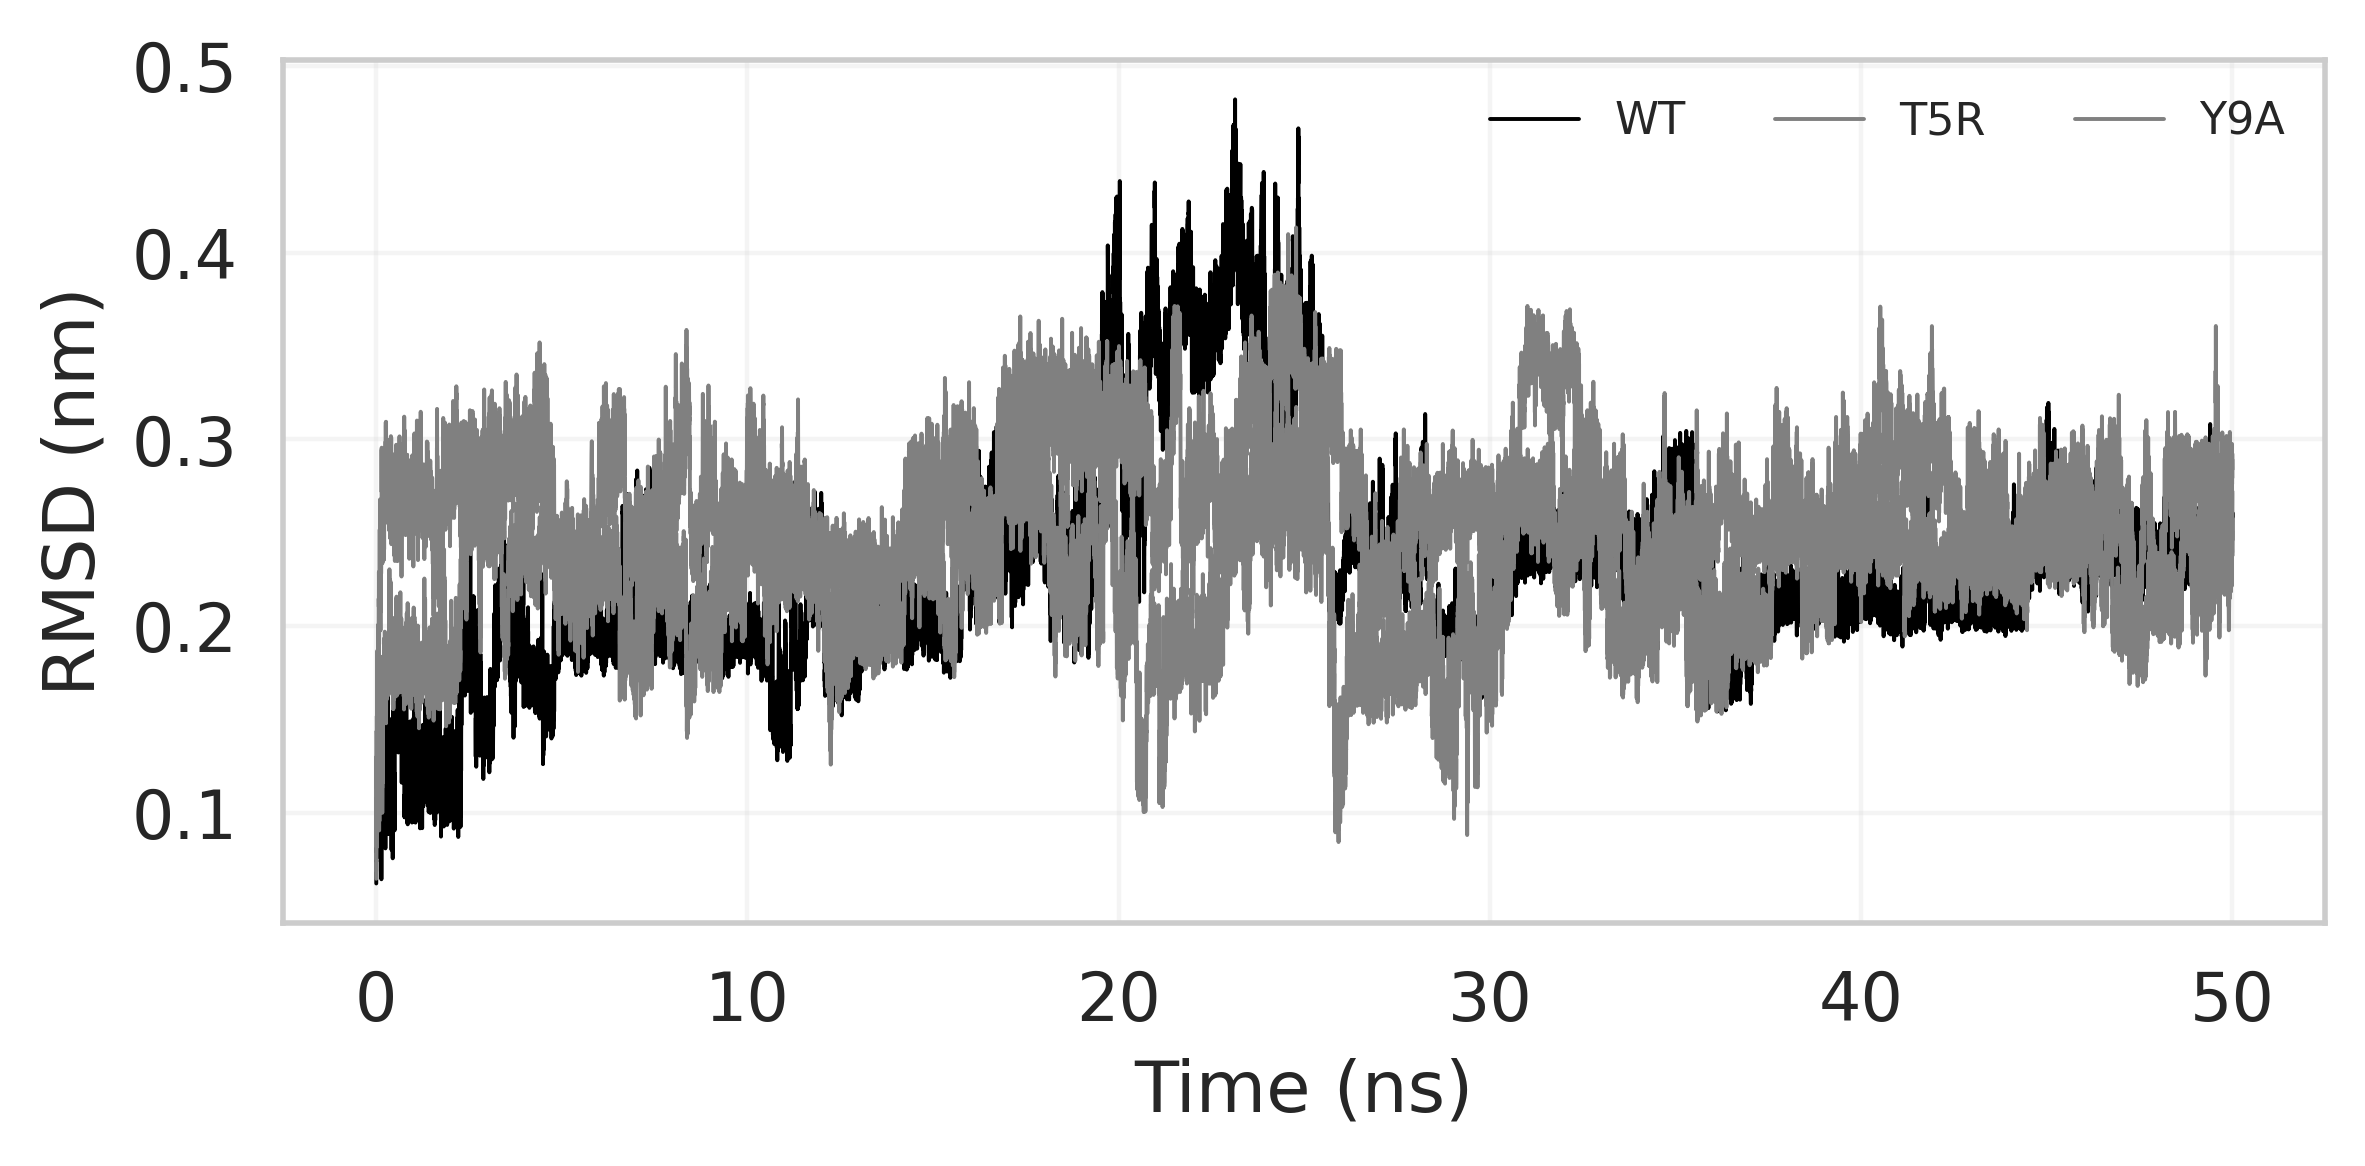

In [7]:
stride = 1  # increase to thin the trajectory (e.g., 10)
max_points = 50000

color_map = {
    "WT": "black",
    "D2M": res_colors.get(2, "orange"),
    "Y0A": res_colors.get(0, "red"),
}

fig, ax = plt.subplots(figsize=(6, 3), dpi=200)
for mutant, df in traj_data.items():
    plot_df = df.iloc[::stride][:max_points].copy()
    ax.plot(
        plot_df["time"] / 1e3,
        plot_df["rmsd"],
        lw=0.7,
        color=color_map.get(mutant, "gray"),
        label=mutant,
    )

ax.set_xlabel("Time (ns)")
ax.set_ylabel("RMSD (nm)")
ax.grid(alpha=0.2)
ax.legend(frameon=False, fontsize=8, ncol=3, loc="upper right")
plt.tight_layout()


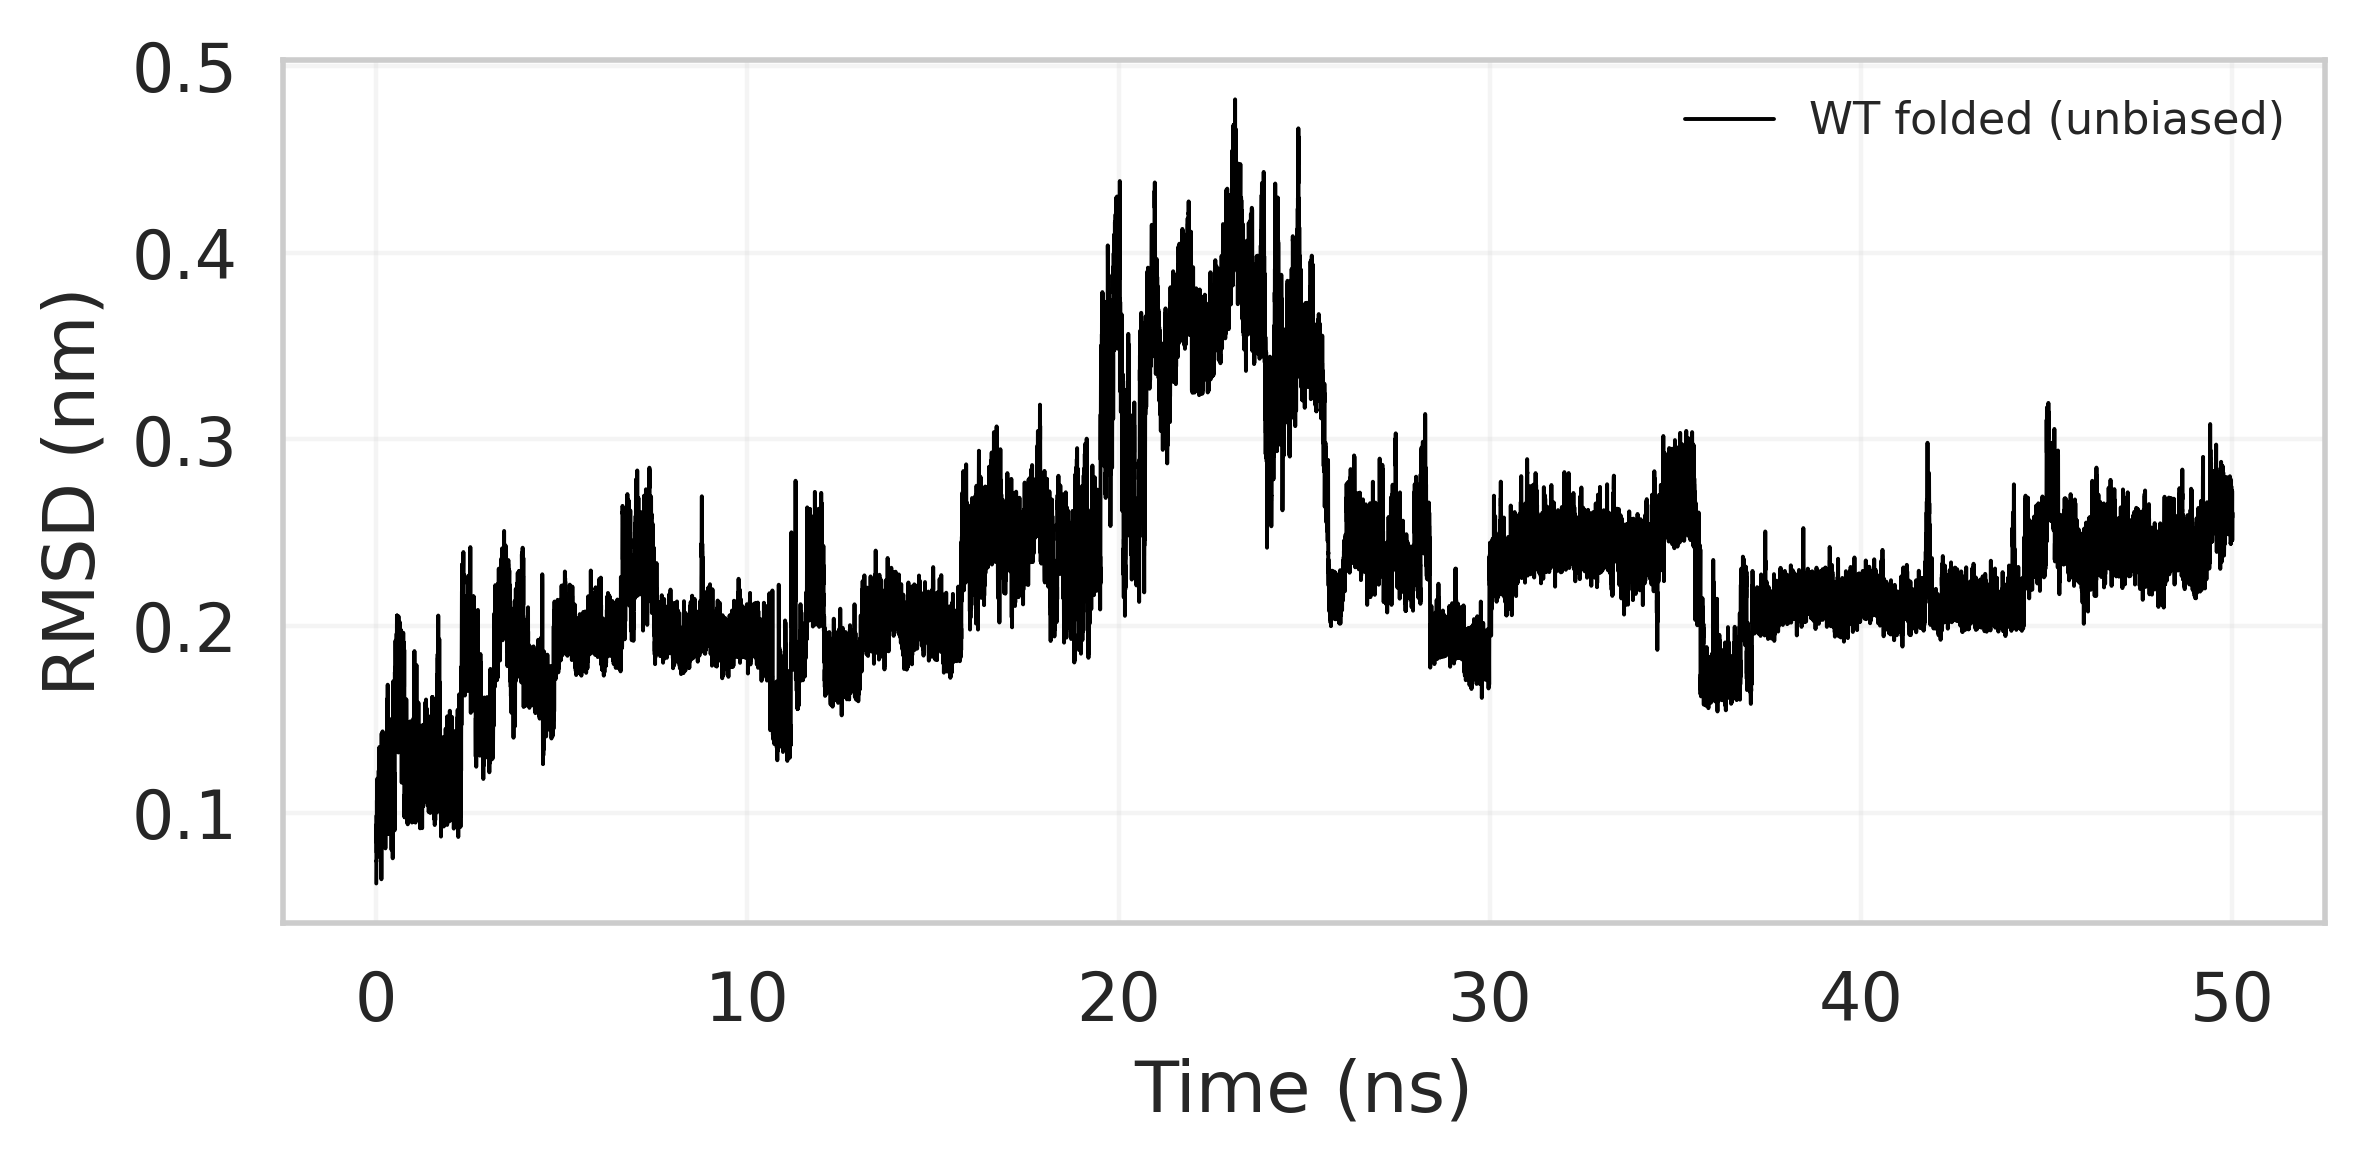

In [8]:
# WT folded unbiased RMSD from local trajectory files
wt_folded_path = traj_root / "WT" / "COLVAR_CV_F"
if not wt_folded_path.exists():
    raise FileNotFoundError(f"Missing local folded WT trajectory file: {wt_folded_path}")

wt_rmsd_col = pick_rmsd_column(wt_folded_path)
wt_folded_df = load_colvar(
    wt_folded_path,
    usecols=["time", wt_rmsd_col],
    nrows=None,
).rename(columns={wt_rmsd_col: "rmsd"})

stride_plot = stride if "stride" in globals() else 1
max_points_plot = max_points if "max_points" in globals() else 50000

fig, ax = plt.subplots(figsize=(6, 3), dpi=200)
plot_df = wt_folded_df.iloc[::stride_plot][:max_points_plot].copy()
ax.plot(
    plot_df["time"] / 1e3,
    plot_df["rmsd"],
    lw=0.7,
    color="black",
    label="WT folded (unbiased)",
)

ax.set_xlabel("Time (ns)")
ax.set_ylabel("RMSD (nm)")
ax.grid(alpha=0.2)
ax.legend(frameon=False, fontsize=8, loc="upper right")
plt.tight_layout()
